# 🏠 House Prices — Exploratory Data Analysis (EDA)

**Goal:** Understand the data distribution, correlations, and key patterns before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
sns.set_palette("muted")


## 1. Load Raw Data

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)


Train shape: (1460, 81)
Test shape : (1459, 80)


## 2. Dataset Overview

In [3]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
train.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 3. Missing Values Analysis

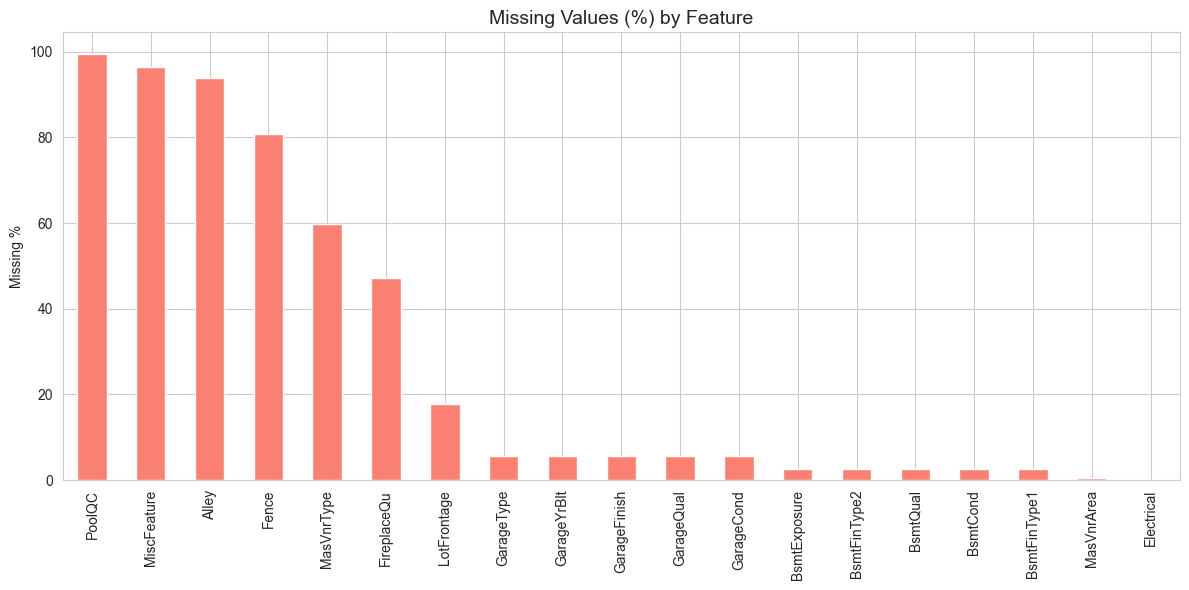

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [6]:
missing_pct = (train.isnull().sum() / len(train) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing_pct.plot(kind="bar", color="salmon")
plt.title("Missing Values (%) by Feature", fontsize=14)
plt.ylabel("Missing %")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/plots/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print(missing_pct)


In [7]:
print("Duplicate rows:", train.duplicated().sum())


Duplicate rows: 0


## 4. Target Variable — SalePrice Analysis

In [8]:
print(train["SalePrice"].describe())
print(f"\nSkewness : {train['SalePrice'].skew():.4f}")
print(f"Kurtosis : {train['SalePrice'].kurt():.4f}")


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness : 1.8829
Kurtosis : 6.5363


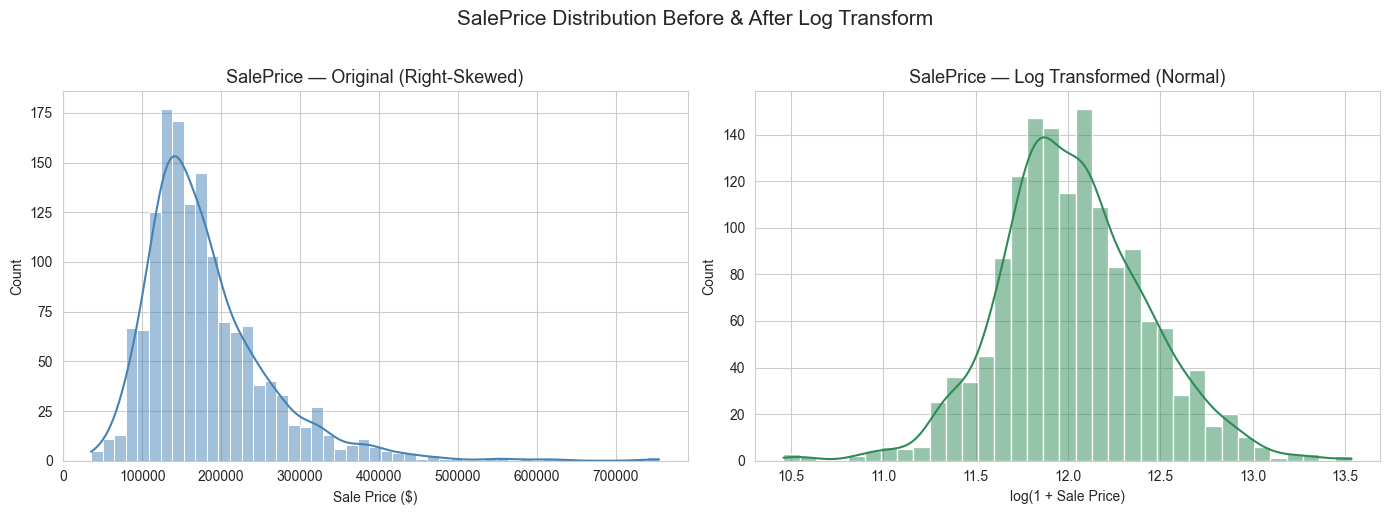

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice — Original (Right-Skewed)", fontsize=13)
axes[0].set_xlabel("Sale Price ($)")

# Log-transformed
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("SalePrice — Log Transformed (Normal)", fontsize=13)
axes[1].set_xlabel("log(1 + Sale Price)")

plt.suptitle("SalePrice Distribution Before & After Log Transform", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/plots/saleprice_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Correlation Analysis

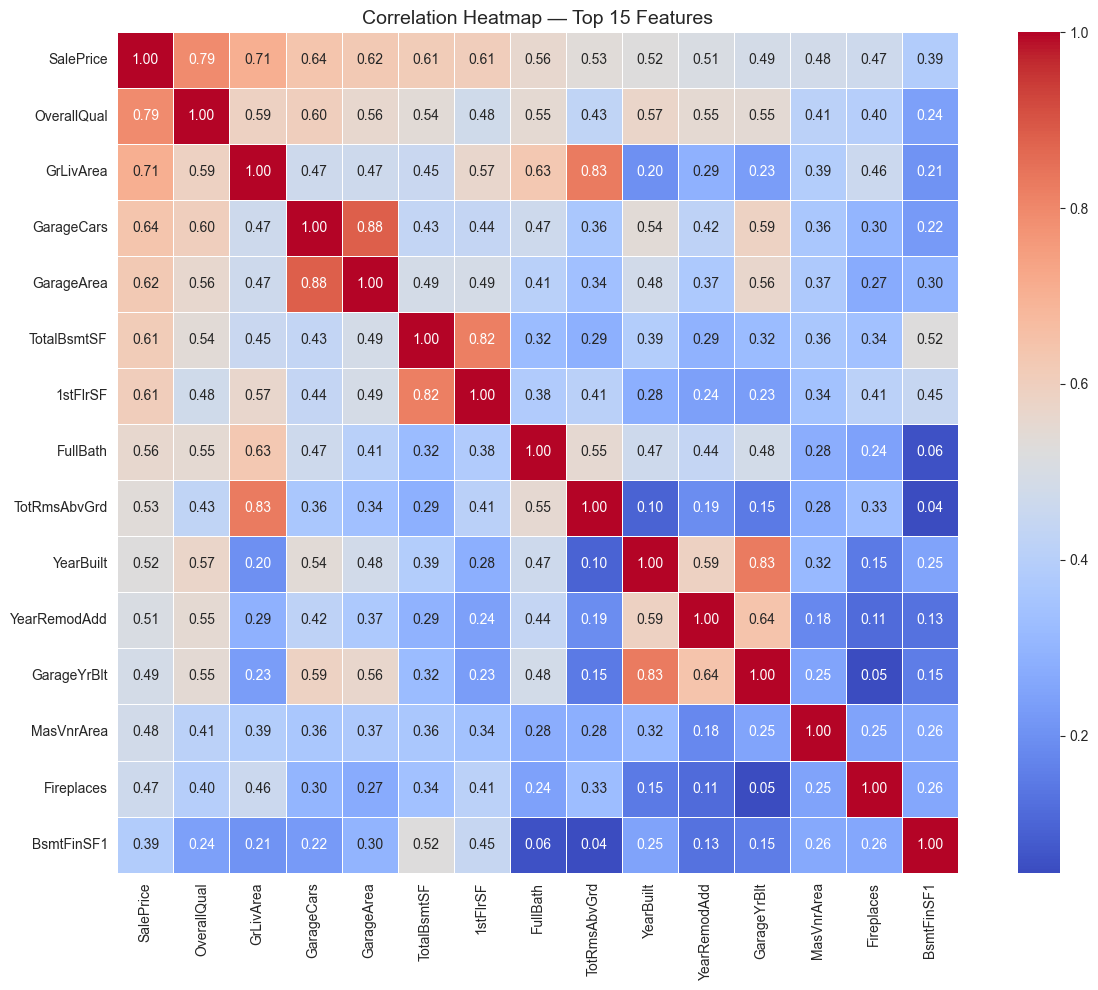

In [10]:
corr = train.corr(numeric_only=True)
top_features = corr["SalePrice"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr[top_features].loc[top_features],
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, square=True
)
plt.title("Correlation Heatmap — Top 15 Features", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/plots/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
top_corr = corr["SalePrice"].sort_values(ascending=False).head(11)[1:]  # exclude SalePrice itself
print("Top 10 features correlated with SalePrice:")
print(top_corr)


Top 10 features correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


## 6. Key Feature Analysis

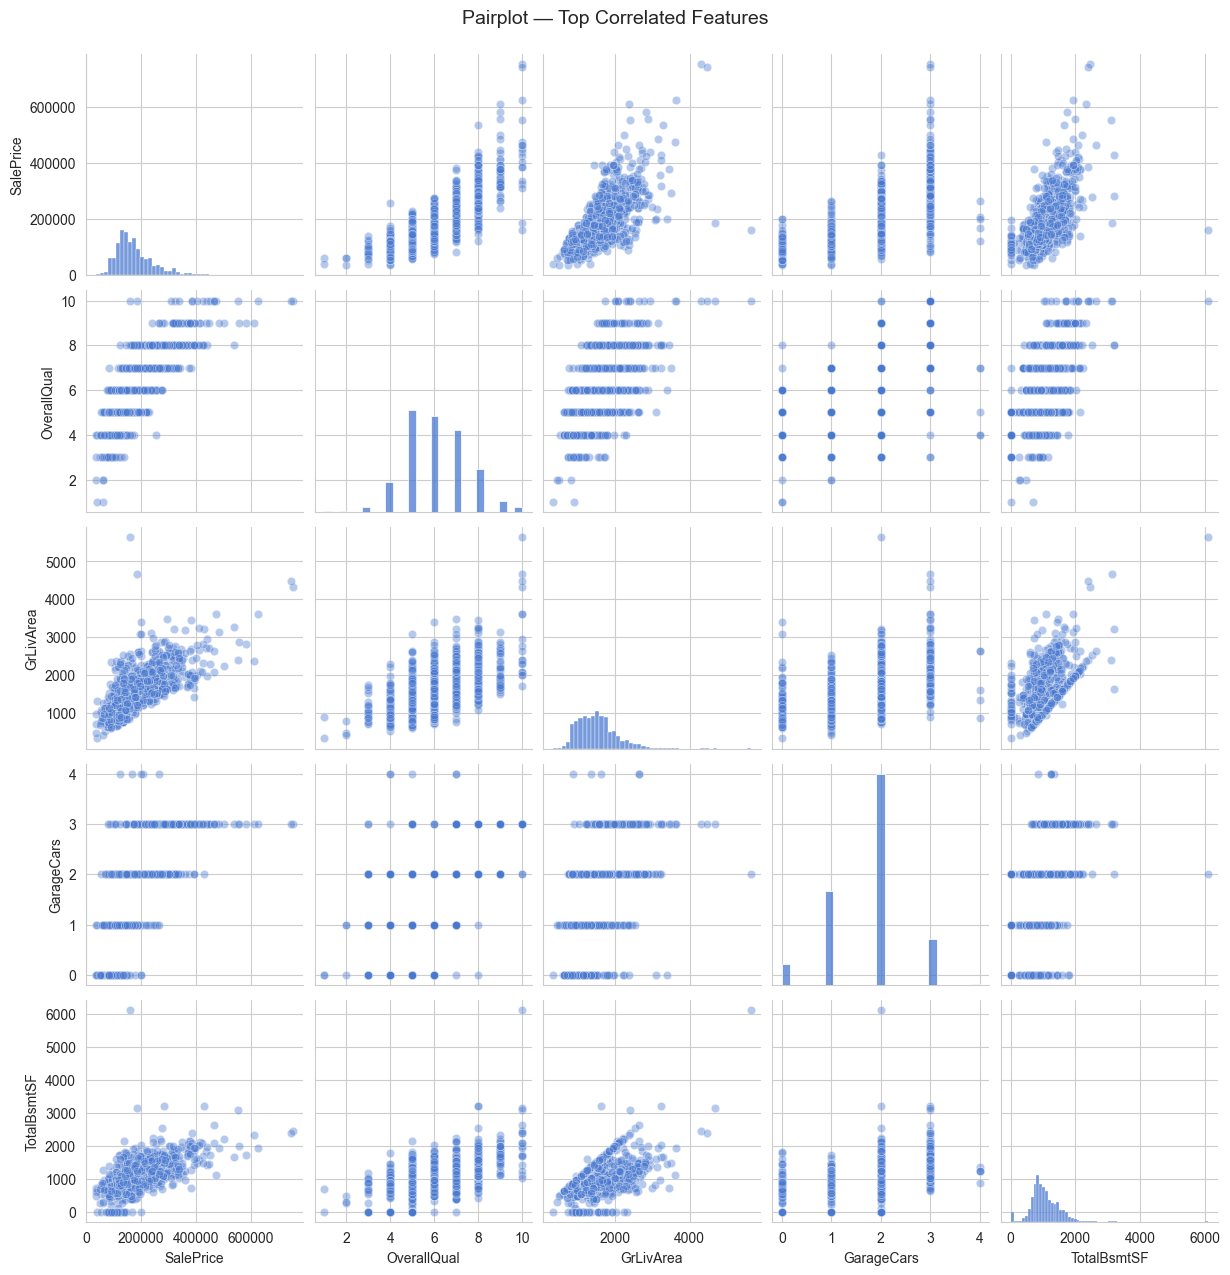

In [12]:
# Pairplot — top 5 correlated features
cols = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF"]
g = sns.pairplot(train[cols], plot_kws={"alpha": 0.4})
g.fig.suptitle("Pairplot — Top Correlated Features", y=1.02, fontsize=14)
plt.savefig("../outputs/plots/pairplot_top_features.png", dpi=100, bbox_inches="tight")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_12620\3055524605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train["OverallQual"], y=train["SalePrice"], palette="Blues")


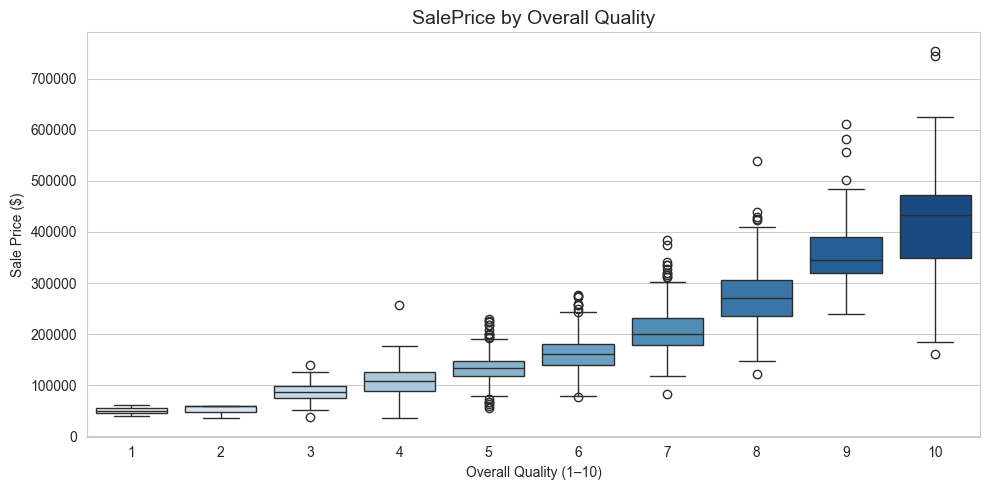

In [13]:
# OverallQual vs SalePrice
plt.figure(figsize=(10, 5))
sns.boxplot(x=train["OverallQual"], y=train["SalePrice"], palette="Blues")
plt.title("SalePrice by Overall Quality", fontsize=14)
plt.xlabel("Overall Quality (1–10)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.savefig("../outputs/plots/quality_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Neighborhood Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_12620\394143528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


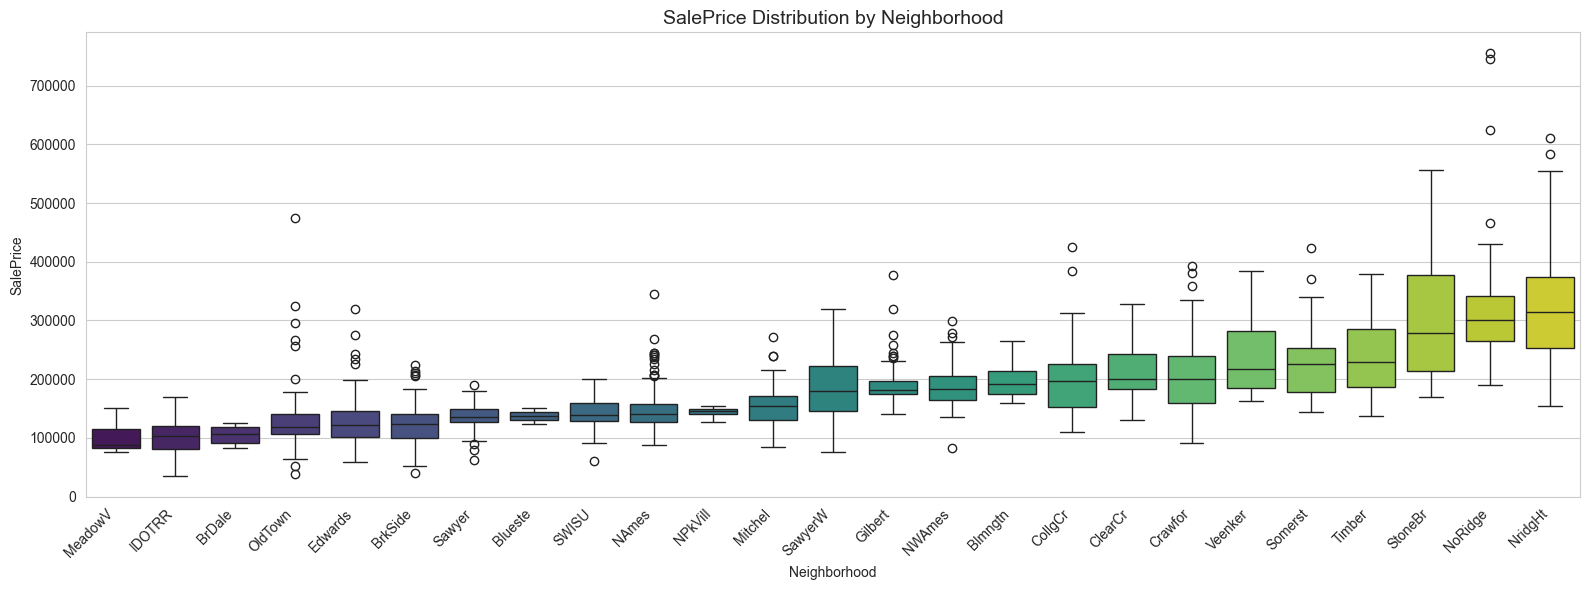

In [14]:
plt.figure(figsize=(16, 6))
neighborhood_order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(
    data=train, x="Neighborhood", y="SalePrice",
    order=neighborhood_order, palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.title("SalePrice Distribution by Neighborhood", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/plots/neighborhood_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Year Built vs Sale Price

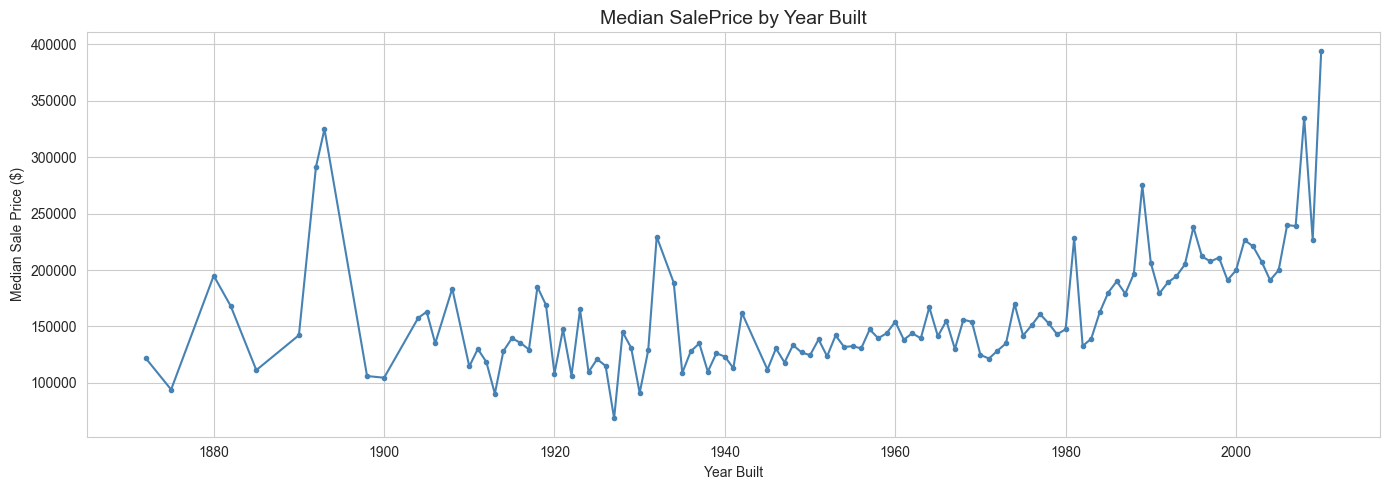

In [15]:
plt.figure(figsize=(14, 5))
train.groupby("YearBuilt")["SalePrice"].median().plot(kind="line", marker="o", markersize=3, color="steelblue")
plt.title("Median SalePrice by Year Built", fontsize=14)
plt.xlabel("Year Built")
plt.ylabel("Median Sale Price ($)")
plt.tight_layout()
plt.savefig("../outputs/plots/yearbuilt_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Outlier Detection

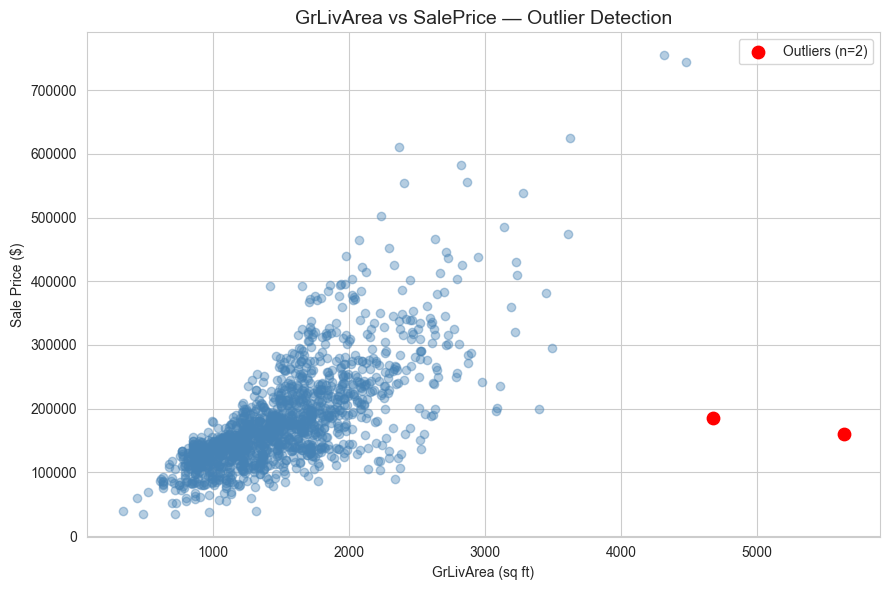

Outliers to remove: 2


In [16]:
# GrLivArea vs SalePrice — Famous outliers
plt.figure(figsize=(9, 6))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.4, color="steelblue")

# Highlight outliers
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
plt.scatter(outliers["GrLivArea"], outliers["SalePrice"],
            color="red", s=80, label=f"Outliers (n={len(outliers)})", zorder=5)

plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("Sale Price ($)")
plt.title("GrLivArea vs SalePrice — Outlier Detection", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/outlier_detection.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Outliers to remove: {len(outliers)}")


In [17]:
print("✅ EDA Completed Successfully!")


✅ EDA Completed Successfully!
